In [2]:
from dotenv import load_dotenv
import os 
load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("True")
else:
    print("False")

True


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")
llm

ChatGoogleGenerativeAI(profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x000001D6556FBA10>, default_metadata=(), model_kwargs={})

#### **Messages Graph**

In [4]:
from langchain_core.messages import HumanMessage

llm.invoke([HumanMessage(content="I want to know the meaning of water")]).content

'Water is far more than just H2O; its "meaning" is incredibly vast and multifaceted, encompassing scientific, biological, environmental, cultural, philosophical, and metaphorical dimensions.\n\nHere\'s a breakdown of its various meanings:\n\n---\n\n### 1. The Scientific & Physical Meaning\n\n*   **Chemical Composition:** Water is a chemical compound with the formula H₂O, meaning each molecule contains one oxygen and two hydrogen atoms.\n*   **States of Matter:** It\'s unique in existing naturally on Earth in three states: solid (ice), liquid (water), and gas (water vapor/steam).\n*   **Universal Solvent:** Its polarity makes it an excellent solvent, dissolving more substances than any other liquid. This is crucial for biological processes.\n*   **Density Anomaly:** Unlike most substances, water is less dense as a solid (ice) than as a liquid. This allows ice to float, preventing oceans and lakes from freezing solid from the bottom up, which is vital for aquatic life.\n*   **High Specif

In [5]:
from typing import TypedDict,List, Annotated
from operator import add

class graph_schema(TypedDict):
    messages_manual = List
    messages_auto = Annotated[List,add]

In [6]:
from langchain_core.messages import AIMessage

def create_post(state:graph_schema)->graph_schema:
    messages_manual = state['messages_manual']
    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state['messages_manual'] = messages_manual + [response_manual_ai]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_manual_ai]

    return state

def curate_post(state:graph_schema)->graph_schema:
    messages_manual = state['messages_manual']
    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=messages_manual)
    state['messages_manual'] = messages_manual + [response_manual]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content = response_auto)
    state['messages_auto'] = [response_auto_ai]

    return state

In [10]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)

graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)

messages_graph = graph.compile()


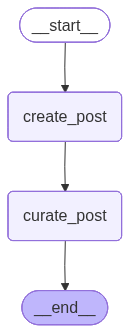

In [11]:
from IPython.display import display,Image
Image(messages_graph.get_graph().draw_mermaid_png())

In [17]:
messages_graph.invoke(
    {'messages_manual' : [HumanMessage(content="The importance of data privacy in the digital age")],
     "messages_auto" : [HumanMessage(content = " The importance of data privacy in the digital age")]}
)

KeyError: 'messages_manual'